In [141]:
import torch

In [142]:
torch.__version__

'2.10.0+cpu'

In [143]:
# step function
def step_function(x):
  return (x >= 0).float()


In [144]:
# y = 0.5x1 + 0.5x2 - 0.7
x = torch.tensor([
    [0.0, 0.0],[0.0, 1.0], [1.0, 0.0], [1.0, 1.0]
])
w = torch.tensor([[0.5], [0.5]])
b = -0.7

# 배치행렬곱을 지원(broadcasting 포함)
# (batch, n, m) @ (batch, m, n)
z =  torch.matmul(x,w) + b
# 계단함수 통과
output = step_function(z)
for x_val, out_val in  zip(x, output):
  print(f'입력 {x_val} 출력 {out_val}')

입력 tensor([0., 0.]) 출력 tensor([0.])
입력 tensor([0., 1.]) 출력 tensor([0.])
입력 tensor([1., 0.]) 출력 tensor([0.])
입력 tensor([1., 1.]) 출력 tensor([1.])


xor : 입력이 서로 다를때문 1을 출력

In [145]:
# 임의로 가중치를 xor
w_xor = torch.randn(2,1)
b_xor = torch.randn(1)
print(f'가중치 w : {w_xor} b : {b_xor}')

z = torch.matmul(x,w_xor) + b_xor
output_xor = step_function(z)
for x_val, out_val in  zip(x, output):
  corrent_target = int(x_val[0] != x_val[1])
  print(f'입력 {x_val} 출력 {out_val} 정답 : {corrent_target}')

가중치 w : tensor([[0.3367],
        [0.1288]]) b : tensor([0.2345])
입력 tensor([0., 0.]) 출력 tensor([0.]) 정답 : 0
입력 tensor([0., 1.]) 출력 tensor([0.]) 정답 : 1
입력 tensor([1., 0.]) 출력 tensor([0.]) 정답 : 1
입력 tensor([1., 1.]) 출력 tensor([1.]) 정답 : 0


다층퍼셉트론 : 은닉층(hidden layer)

활성화함수 : 시그모이드나 ReLU 같은 파생 활성화 함수

In [146]:
# x = [1.0, 0.0]
# z1 = w11 * x1 + w21 * x2 + b1
# z2 = w12 * x1 + w22 * x2 + b2
# ....

# z = x*w +b

# z의 값에 활성화함수 시그모이드 씌우면 - 값이 아무리 크거가 작아도  0 ~ 1사이로 압축
# 직선이였던 데이터 공간이 곡면으로 휘어짐

# x
# z = xw1 + b1
# h = sigmoid(z)
# z2 = hw2 + b2
# y  = sigmoid(z2)
# 최종예측 y

# 입력 2 /  은닉층 2개 뉴런  / 출력 1개의 뉴런
# x = [1.0, 0.0]   (1,2)
# w1 = [
#     20 -20
#     20 -20
# ]
# b = [-10, 30]
# W2 = [20
#       20
#       ]
#  b2 = [-30]
# 은닉층 선형결합
#  z = [1.0, 0.0] @ [20 -20      + [-10,30]  = [10,10]
#                    20 -20]
# 시그모이드 [0.9999,0.9999]
# 출력층 [0.999,0.999]@[20
#                         20  + (-30)   = 39.998 -30 = 9.998
#                        ]
# 출력활성화 시그모이드(9.998) =  0.999999  판정 1


In [147]:
# 활성화 함수의 필요성  선형붕괴(활성화 함수 없이 층을 쌓으면 의미가 없다)
# 1층 h = W1 * x + B1
# 2층 y = W2 * h + B2 = W2(W1 * x + B1) + B2
# W2*W1*x + W2*B1 + B2
# W' = W2W1  b' = W2b1 + b2
# y = W'x + b'

# 활성화 함수는 공간변형 도구

# 계단함수는 판단은 가능하지만 학습은 불가능(미분 불가능 , 기울기 알수 없음, 기울기 0)

In [148]:
import torch
torch.sigmoid( torch.tensor(-10))

tensor(4.5398e-05)

$
\sigma(x) = \frac{1}{1 + e^{-x}}
$

$
\sigma'(x) = \sigma(x)\left(1 - \sigma(x)\right)
$

In [149]:
# x   시그모이드    시그모이드 미분
# 0      0.5           0.25   가장 활발하게 학습
#+- 2   0.88/0.12     0.10  학습속도 둔화
# +- 5  0.99/0.01     0.0067  거의 학습이 안됨
# +- 10 1/0            0      완전정지(뉴런사망)

In [150]:
# torch 자동미분 기능
import  torch
x = torch.tensor([10.0], requires_grad=True)
y = torch.sigmoid(x)
y.backward()
print(x.grad)

tensor([4.5417e-05])


In [151]:
# ReLU
# f(x) = z  = max(0,x)
import numpy as np
x = np.array([-5,0,2,6,-5])
np.maximum(0,x)

array([0, 0, 2, 6, 0])

In [152]:
# ReLU는 미분을 하면 양수구간은 항상 1
# 1 *1 *1 *1 == 1  기울기가 죽지 않고 끝까지 전달
# 입력이 음수면 기울기가 0 출력이 비활성화 -> 계산중에 불필요한 뉴런을 제거하는 효과
# 시그모이드보다 6배이상 빠르고 안정적으로 학습이 가능

In [153]:
# 활성화 없이 100층 = 선형 붕괴
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [154]:
# 케라스

In [155]:
%pip install tensorflow

In [156]:
import tensorflow as tf

In [157]:
fasion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [158]:
(x_train_full,y_train_full),(x_test,y_test) =   fasion_mnist
x_train_full.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [159]:
x_train, y_train = x_train_full[:-5000],y_train_full[:-5000]
x_valid, y_valid = x_train_full[-5000:],y_train_full[-5000:]
x_train.shape, x_valid.shape

((55000, 28, 28), (5000, 28, 28))

In [160]:
x_train,x_valid,x_test = x_train / 255. , x_valid / 255. , x_test / 255.

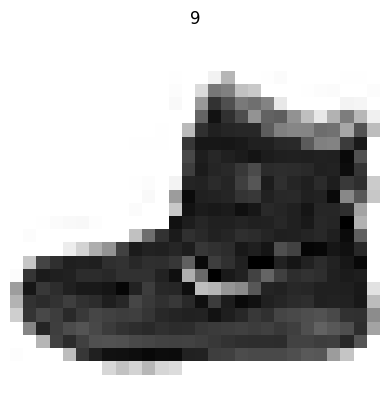

In [161]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0],cmap='binary')
plt.axis('off')
plt.title(y_train[0])
plt.show()

In [162]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [163]:
# 다중분류 (multi class, 단일 정답)
# 마지막 출력층  softmax  = 모든 출력의 합이 1, 확률 분포형태
# 각 클래스별로 확률값
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add( tf.keras.layers.Input(shape=(28,28)) )
model.add( tf.keras.layers.Flatten())
model.add( tf.keras.layers.Dense(300, activation='relu'))
model.add( tf.keras.layers.Dense(100, activation='relu'))
model.add( tf.keras.layers.Dense(10, activation='softmax'))  # 마지막 확률분포

In [164]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
784*300 + 300

235500

In [166]:
model.layers

[<Flatten name=flatten_2, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>]

In [167]:
# 컴파일
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'sgd',
    metrics = ['accuracy']
)

In [168]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7642 - loss: 0.7140 - val_accuracy: 0.8288 - val_loss: 0.4993
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8333 - loss: 0.4813 - val_accuracy: 0.8420 - val_loss: 0.4495
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8467 - loss: 0.4384 - val_accuracy: 0.8484 - val_loss: 0.4268
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8556 - loss: 0.4121 - val_accuracy: 0.8540 - val_loss: 0.4115
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8617 - loss: 0.3927 - val_accuracy: 0.8564 - val_loss: 0.4013
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8671 - loss: 0.3770 - val_accuracy: 0.8594 - val_loss: 0.3930
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8715 - loss: 0.3638 - val_accuracy: 0.8612 - val_loss: 0.3871
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8754 - loss: 0.3522 

In [169]:
predict = model.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [170]:
np.argmax(predict, axis= 1)

array([9, 2, 1, 1, 6])

In [171]:
y_test[:5]

array([9, 2, 1, 1, 6], dtype=uint8)

In [172]:
predict = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [173]:
sum(np.argmax(predict,axis=1) == y_test) / len(y_test)

np.float64(0.8749)

In [175]:
from sklearn.metrics import classification_report
print(classification_report(y_test, np.argmax(predict,axis=1)))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.75      0.85      0.80      1000
           3       0.80      0.93      0.86      1000
           4       0.81      0.79      0.80      1000
           5       0.89      0.98      0.94      1000
           6       0.78      0.63      0.70      1000
           7       0.95      0.91      0.93      1000
           8       0.96      0.96      0.96      1000
           9       0.98      0.93      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [178]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
# x축은 range(30)
# y축은 loss, val_loss
# plt.plot

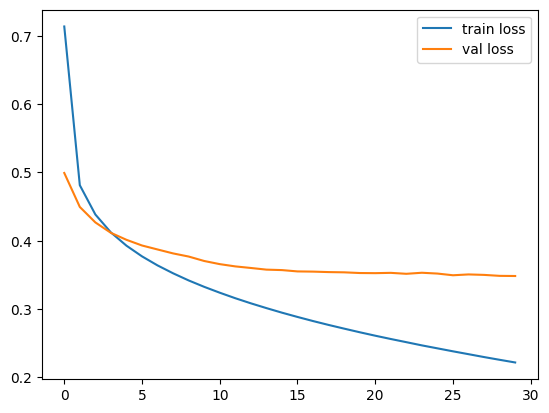

In [180]:
import matplotlib.pyplot as plt
plt.plot(range(30), history.history['loss'], label = 'train loss')
plt.plot(range(30), history.history['val_loss'], label = 'val loss')
plt.legend()
plt.show()